In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
import polars as pl

In [2]:
#problem 1 
#e)
df = pd.read_csv('../data/DolphinInteractions/dolphin.csv', header=None)
A = (df.to_numpy() >= 5).astype(int) #convert df to array, zeroing values below 5
np.fill_diagonal(A, 0) #fill the diagonal of A with 0

ones = np.ones(A.shape[0], dtype=int) #create a vector of ones the length of A

#i
k = A @ ones #multiply matrix and ones vector to get i) degrees of each node
print('k degrees =', k)

#ii
m = 0 #set edges to 0
for i in range(A.shape[0]): #double summation from our formula in form of for loop
    for j in range(A.shape[1]): #sum all values of Aij
        m += A[i, j]

m = int(m / 2)
print('m, edges =', m)

#iii
N = A @ A #A^2 
print('common neighbors for 0,3 =', N[0,3]) #find common neighbors at 0,3 of N

#iv
triangles = int(np.trace(A @ A @ A) / 6) #trace A^3 and divide by 6
print('triangles =', triangles) 


k degrees = [5 5 5 4 5 2 6 2 1 1 2 2 2]
m, edges = 21
common neighbors for 0,3 = 3
triangles = 18


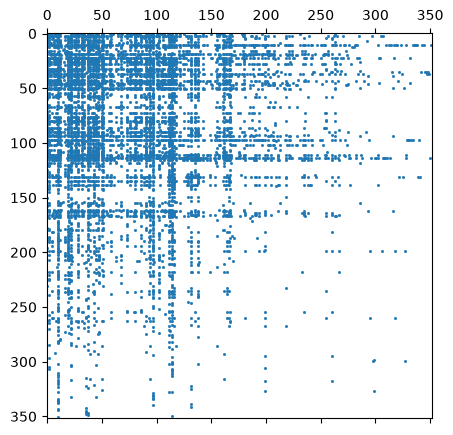

In [13]:
#problem 2
df = pl.read_csv('../data/BTSFlights/BTS2025.csv')
df = df.filter(pl.col('PASSENGERS') > 1000)
G = nx.DiGraph(df[['ORIGIN', 'DEST']].rows())
lscc = max(nx.strongly_connected_components(G), key=len)
G = G.subgraph(lscc).copy()
# variables that you may need
nodedict = {node: i for i, node in enumerate(G.nodes)}
reverse_nodedict = {i: node for i, node in enumerate(G.nodes)}
A = nx.to_numpy_array(G, nodelist=nodedict.keys(), dtype=int)

#a)
plt.figure(figsize=(12,5))
plt.spy(A,markersize=1)
plt.show()

In [6]:
# b)
def A_diameter(A):
    adjacency = np.asarray(A) > 0 #create array of adjacency matrix
    n = adjacency.shape[0] #length of A
    reachable = np.eye(n, dtype=bool) #create matrix of reachable nodes
    power = adjacency.copy() #copy of array used to scale with powers

    for distance in range(1, n):
        reachable |= power #bitwise or reachable and power to find new reachable nodes while keeping already reached nodes
        if reachable.all(): #return the distance (diameter) if all nodes are reachable
            return distance 
        power = power @ adjacency #increase the power by multiplying byself

    return None

print('calculated diameter =', A_diameter(A))
print('networkx diameter =', nx.diameter(G))

calculated diameter = 6
networkx diameter = 6


In [10]:
# c)
for flights in range(1, 5): 
    A_power = np.linalg.matrix_power(A, flights) #raise matrix A to the power of flights
    reachable_airports = int(np.count_nonzero(A_power[nodedict['CHO']] > 0)) #count the nonzero(reachable) nodes in A_power mapped to CHO node
    print(f'{flights} flight: {reachable_airports}')

1 flight: 5
2 flight: 198
3 flight: 348
4 flight: 351


In [21]:
# d)
out_degree = A.sum(axis=1) #find out degree by summing A across the rows
top5_indices = np.argsort(out_degree)[-5:][::-1] #argsort outdegree and get the top out degree airport indices

#create table of airport and out degree using indicies
top5_airports = pd.DataFrame({'airport': [reverse_nodedict[i] for i in top5_indices], 'out degrees': [int(out_degree[i]) for i in top5_indices]}) 

print(top5_airports)

  airport  out degrees
0     DFW          177
1     DEN          164
2     ATL          153
3     ORD          148
4     CLT          133


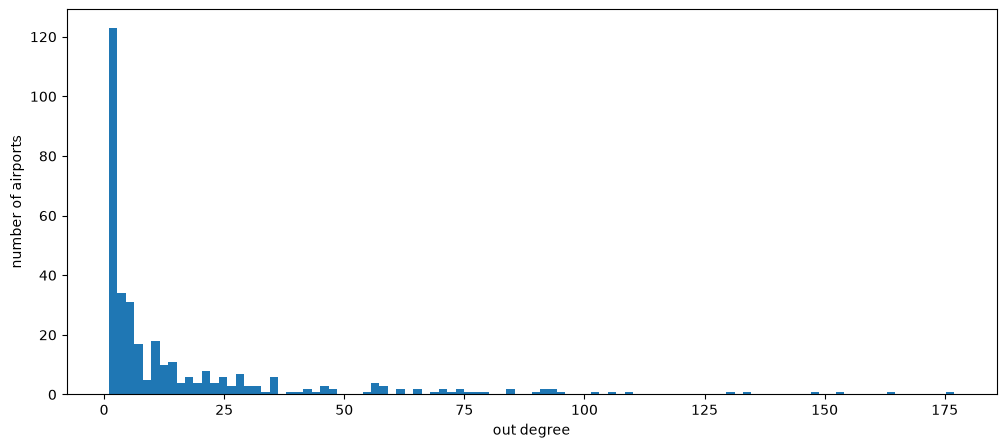

In [ ]:
# e)
plt.figure(figsize=(12, 5))
plt.hist(out_degree, bins= 100)
plt.xlabel('out degree')
plt.ylabel('number of airports')
plt.show()

#the histogram is heavily skewed resembling a logarithmic shape.  
#understandably, a majority of airports have few direct flights and therefore have low out degrees,
#while there are a few airports that serve as hubs, with many connecting flights and high out degrees.